## Testing Sampling From Language Model

In [1]:
import json
import requests
import re
import argparse
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional
from datasets import load_from_disk
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from vpud_utils import calculate_entropy
from regression_data_processing import parse_features_to_note, create_x_row_from_x_features, create_x_row_from_x_range
from bayesian_optimisation import new_candidate

/data2/users/ij23/micromamba_root/micromamba/envs/vpud/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
port = 6000
llm = "qwen14b-base"
dataset = "logistic_regression_3"
selected_feature = "x1"

In [3]:
global_seed = 123
shots = 30

#### Set Up

In [4]:
def get_response(prompt, label_keys, seed):
    # Add label_keys to the payload
    payload = {
        'prompt': prompt,
        'label_keys': label_keys,
        'seed': seed
    }
    
    # Send POST request to the server
    response = requests.post(f'http://localhost:{port}/predict', json=payload).json()
    
    # Extract response text and probabilities from the server's response
    response_text = response.get('response_text', "")
    probabilities = response.get('probabilities', [])
    
    return response_text, probabilities

In [5]:
### Prompts

def short_prompt(incontext_examples: list[str], example: str, *args, **kwargs):
    incontext_examples_str = "\n".join(incontext_examples)
    
    prompt = f"""{incontext_examples_str}\n {example} <output>"""
    
    return prompt

def note_label_prompt(note: str, label: str):
    prompt = f""" {note} <output>{label}</output>"""
    
    return prompt

def note_label_df_to_icl_examples(
        note_label_df: pd.DataFrame,
        seed: int,
        z_note: Optional[str] = None,
        u_label: Optional[str|int] = None,
    ):
    """
    Converts a DataFrame of notes and labels to incontext examples for LLM.
    Shuffles the DataFrame before converting.
    
    If z_note and u_label are provided, the z_note and u_label will be added to data as well.
    """
    
    if z_note is not None and u_label is not None:
        z_note_label_df = pd.DataFrame([{"note": z_note, "label": u_label}])
        note_label_df = pd.concat([note_label_df, z_note_label_df], ignore_index=True)
        
    note_label_df = note_label_df.sample(frac=1, random_state=seed).reset_index(drop=True)
    
    incontext_examples = []
    
    for _, row in note_label_df.iterrows():
        incontext_examples.append(note_label_prompt(row['note'], row['label']))
    
    return incontext_examples

In [6]:
### Data preprocessing

data_path = f'ToyRegression/logistic_regression_data/{dataset}.csv'

data = pd.read_csv(data_path, index_col=0)

label_name = "y"
label_keys = ["0", "1"]
data = data.rename(columns={label_name: 'label'})
data['label'] = data['label'].astype(int)

feature_columns = [col for col in data.columns if col != 'label']

data, test_data = train_test_split(data, test_size=0.2, random_state=global_seed)

data["note"] = data.apply(lambda row: parse_features_to_note(row, feature_columns), axis=1)

print("Features:", feature_columns)

print("Feature to vary:", selected_feature)

D_rows = data.sample(n=shots, random_state=global_seed)

D_note_label_df = D_rows[['note', 'label']]

D = "\n".join(f" {row['note']} <output>{row['label']}</output>" for _, row in D_rows.iterrows())


Features: ['x1']
Feature to vary: x1


### Sampling

In [7]:
x_features = "{'x1': [0.6]}"
x_range = None

num_llm_seeds = 1
num_permutations = 50

In [8]:
if x_features is not None:
    x_row = create_x_row_from_x_features(x_features, feature_columns)
    num_x_values = len(x_row)
elif x_range is not None:
    x_row = create_x_row_from_x_range(x_range, feature_columns)
    num_x_values = len(x_row)
else:
    raise ValueError("Either x_features or x_range must be provided")

X Row:
     x1  label      note
0  0.6      0  x1 = 0.6


In [ ]:
for j in range(num_x_values):
    x = x_row['note'].iloc[j]
    x_y = x_row['label'].iloc[j]
    print("x:", x)
    
    # Initialize p(y|x)
    pyx_probs_dictionary = {label: np.zeros((num_permutations, num_llm_seeds)) for label in label_keys}
    
    # ----- Processing p(y|x) -----
    for perm_seed in tqdm(range(num_permutations)):
        for llm_seed in range(num_llm_seeds):
            ## p(y|x)

            prompt_pyx = short_prompt(note_label_df_to_icl_examples(D_note_label_df, perm_seed), x)
            
            # print("Prompt for p(y|x,D):")
            # print(prompt_pyx)

            # Get the prediction and probabilities from the model
            pred_pyx, probs_pyx = get_response(prompt_pyx, label_keys, seed=llm_seed)
            # print("pred_p(y|x):", pred_pyx)
            # print("probs_p(y|x):", probs_pyx)
            
            # Accumulate probabilities for puz
            for label, prob in probs_pyx.items():
                pyx_probs_dictionary[label][perm_seed, llm_seed] += prob
                
        # pyx_probs_dictionary = {label: prob / num_llm_seeds for label, prob in pyx_probs_dictionary.items()}
    # print("\nAveraged puzx probabilities:", avg_pyx_probs)
    
    mean = {}
    standard_deviation = {}
    cumulative_mean = {}
    
    for label in label_keys:
        pyx_probs_dictionary[label] = pyx_probs_dictionary[label].squeeze()
        mean[label] = np.mean(pyx_probs_dictionary[label])
        print(f"Mean for {label}: {mean}")
        standard_deviation[label] = np.std(pyx_probs_dictionary[label])
        print(f"Standard deviation for {label}: {standard_deviation}")
        cumulative_sum = np.cumsum(pyx_probs_dictionary[label])
        cumulative_mean[label] = cumulative_sum / np.arange(1, num_permutations + 1)

x: x1 = 0.6


100%|██████████| 50/50 [01:08<00:00,  1.38s/it]

Mean for 0: 0.6754066000000001
Standard deviation for 0: 0.10597351825074036
Mean for 1: 0.3245934
Standard deviation for 1: 0.10597351825074036


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

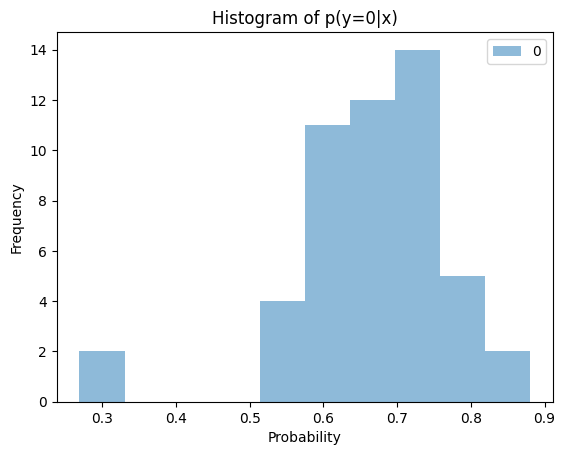

In [11]:
# plot histogram for 0

fig, ax = plt.subplots()
ax.hist(pyx_probs_dictionary["0"], bins=10, alpha=0.5, label='0')

ax.set_xlabel('Probability')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of p(y=0|x)')
ax.legend()


<Axes: ylabel='Density'>

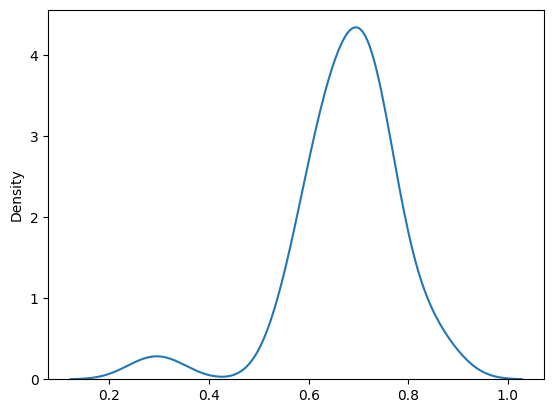

In [12]:
# plot kde for 0

fig, ax = plt.subplots()

sns.kdeplot(pyx_probs_dictionary["0"], ax=ax, label='0')


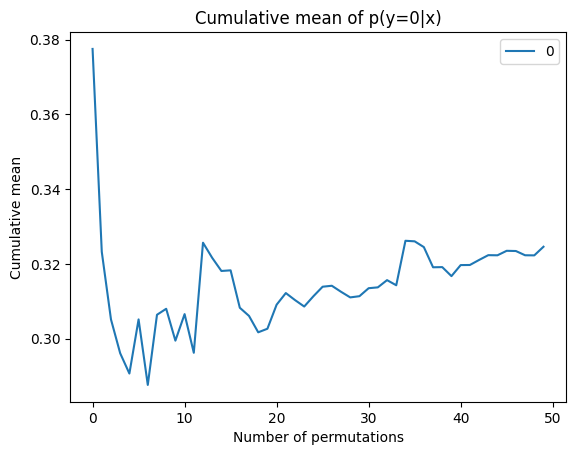

In [ ]:
# Plot cumulative mean for 0
fig, ax = plt.subplots()

plt.plot(cumulative_mean[label], label='0')
plt.xlabel('Number of permutations')
plt.ylabel('Cumulative mean')
plt.title('Cumulative mean of p(y=0|x)')
plt.legend()